In [48]:
import pandas as pd
data = pd.read_csv("../../data/raw_dataset.csv")
data.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

### Gender

In [49]:
counts = data['Gender'].value_counts()
nb_men = counts['Male']
nb_women = counts['Female']

print("Number of women :", nb_women)
print("Number of men   :", nb_men)

# There is almost as many men as women -> balanced

Number of women : 185
Number of men   : 189


### Sleep

In [50]:
print("Average Sleep Duration :", data['Sleep Duration'].mean())
print("Average Sleep Quality :", data['Quality of Sleep'].mean())

# Given the output, we considere that a sleep of good quality is above 7

Average Sleep Duration : 7.132085561497325
Average Sleep Quality : 7.31283422459893


In [51]:
mean_sleep_overweight = data.loc[data['BMI Category'] == 'Overweight', 'Quality of Sleep'].mean()
print("Average Sleep Quality for overweight individuals:", mean_sleep_overweight)

# Overweight people have a slightly lower sleep quality

Average Sleep Quality for overweight individuals: 6.898648648648648


In [52]:
mean_sleep_overweight = data.loc[data['BMI Category'] == 'Obese', 'Quality of Sleep'].mean()
print("Average Sleep Quality for obese individuals:", mean_sleep_overweight)

# Obese people have a low-sleep quality

Average Sleep Quality for obese individuals: 6.4


In [53]:
mean_sport = data['Physical Activity Level'].mean()
mean_sleep_nosport = data.loc[data['Physical Activity Level'] < mean_sport, 'Quality of Sleep'].mean()
print("Average Sleep Quality for non-sportive individuals :", mean_sleep_nosport)

# Non-sportive people have a slightly lower sleep quality

Average Sleep Quality for non-sportive individuals : 6.807453416149069


### Age

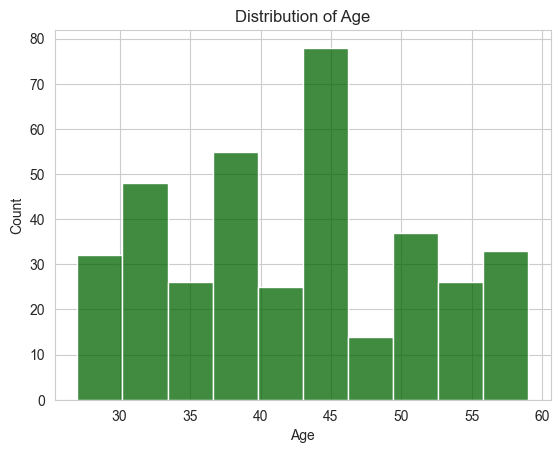

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data['Age'], bins=10, color='darkgreen')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [55]:
min_age = data['Age'].min()
print("Minimum age:", min_age)

max_age = data['Age'].max()
print("Maximum age:", max_age)


Minimum age: 27
Maximum age: 59


                  Metric     Min      Max     Mean
0     Sleep Duration (h)     5.8      8.5     7.13
1  Quality of Sleep (/9)     4.0      9.0     7.31
2           Stress Level     3.0      8.0     5.39
3            Daily Steps  3000.0  10000.0  6817.00
Corrélation entre 'Quality of Sleep' et les autres variables :


,Variable,Correlation_with_QualityOfSleep
3,Sleep Duration,0.883
11,target,0.823
1,Age,0.474
4,Physical Activity Level,0.193
9,Daily Steps,0.017
7,Blood Pressure,-0.029
10,Sleep Disorder,-0.046
2,Occupation,-0.057
6,BMI Category,-0.128
0,Gender,-0.291


/var/folders/yw/wbmnn15566v_cwds7p97ygnc0000gn/T/ipykernel_14501/964662422.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Variable", x="Correlation_with_QualityOfSleep", data=corr_df, palette="coolwarm")


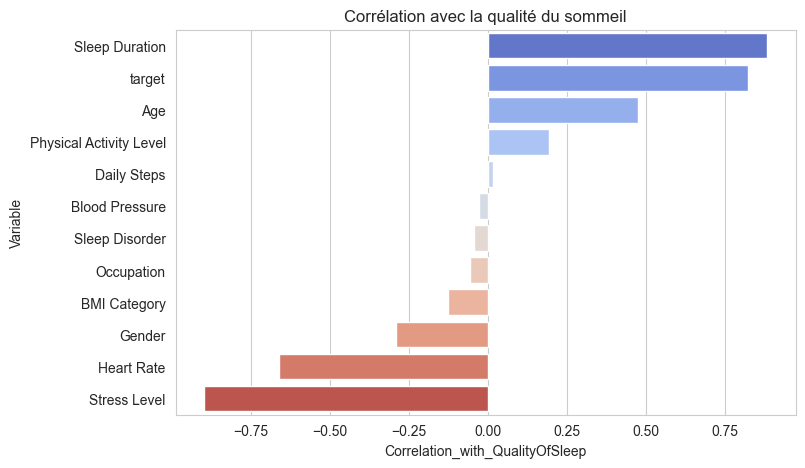

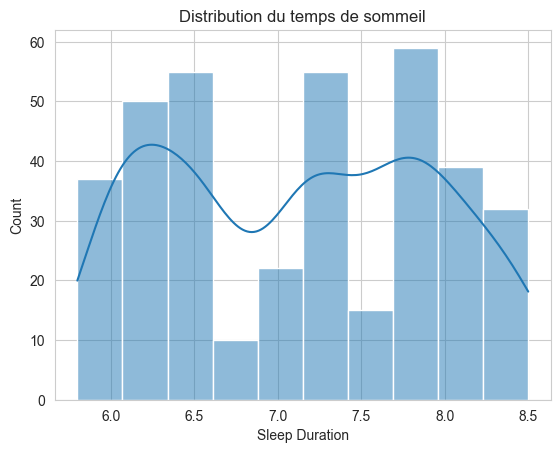

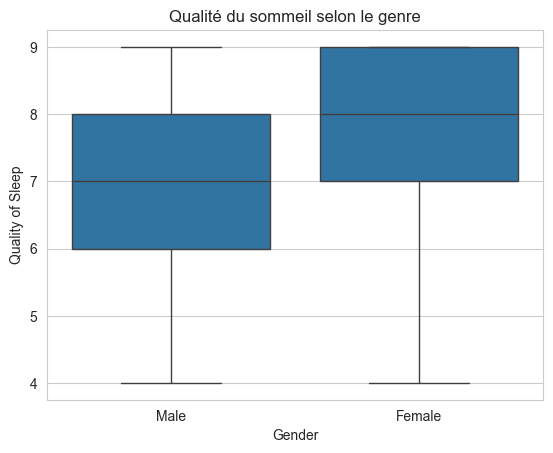

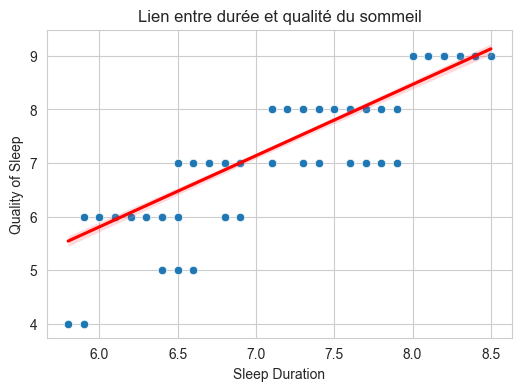

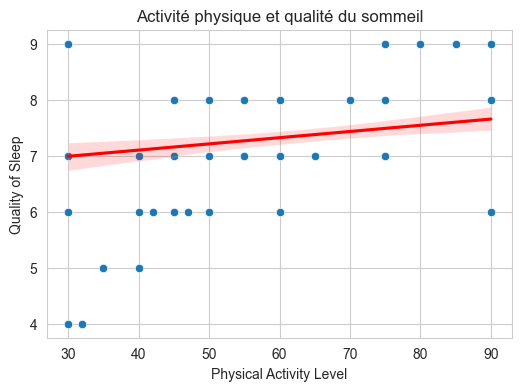

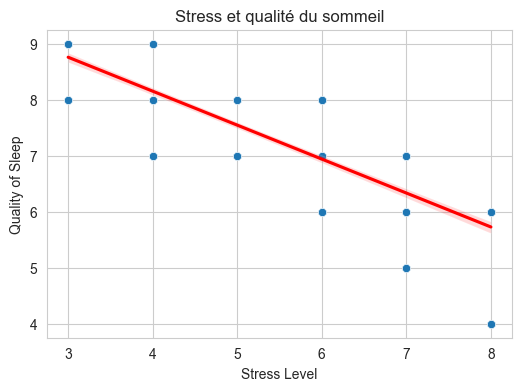

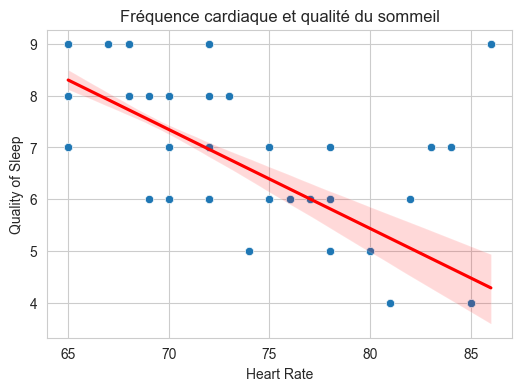

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pointbiserialr, pearsonr

sleep_data = pd.read_csv("../../data/raw_dataset.csv")

#print(sleep_data.info())
#13 colonnes, 374 lignes
#Types de variables :
#  -7 numériques (Age, Sleep Duration, Quality of Sleep, Physical Activity Level, Stress Level, Heart Rate, Daily Steps)
#  -5 qualitatives (Gender, Occupation, BMI Category, Blood Pressure, Sleep Disorder)
#  -1 identifiant (Person ID)

#print(sleep_data.describe())
#print(sleep_data.head())

#print(sleep_data.isnull().sum().sum())
#pas de valeurs manquantes dans le dataset

sleep_data['target'] = (sleep_data['Quality of Sleep'] >= 7).astype(int)
class_counts = sleep_data['target'].value_counts()
#print("Class distribution:\n", class_counts)
pourcentage_good = class_counts.max()/374
pourcentage_bad = class_counts.min()/374
#print(f"\nPourcentage de gens ayant une bonne qualité de sommeil : {pourcentage_good}")   #0.69
#print(f"\nPourcentage de gens ayant une mauvaise qualité de sommeil : {pourcentage_bad}")  #0.31


gender_counts = sleep_data["Gender"].value_counts()
#print("Répartition par genre (counts):")
#print(gender_counts)
#189 hommes et 185 femmes

n_occupations = sleep_data["Occupation"].nunique()
#print(f"\nNombre de professions différentes: {n_occupations}")
#11 professions différentes

sleep_stats  = sleep_data["Sleep Duration"].agg(["min", "max", "mean"]).round(2)
qos_stats    = sleep_data["Quality of Sleep"].agg(["min", "max", "mean"]).round(2)
stress_stats = sleep_data["Stress Level"].agg(["min", "max", "mean"]).round(2)
steps_stats  = sleep_data["Daily Steps"].agg(["min", "max", "mean"]).round(0)

summary = pd.DataFrame({
    "Metric": ["Sleep Duration (h)", "Quality of Sleep (/9)", "Stress Level", "Daily Steps"],
    "Min":  [sleep_stats["min"],  qos_stats["min"],  stress_stats["min"],  steps_stats["min"]],
    "Max":  [sleep_stats["max"],  qos_stats["max"],  stress_stats["max"],  steps_stats["max"]],
    "Mean": [sleep_stats["mean"], qos_stats["mean"], stress_stats["mean"], steps_stats["mean"]],
})
print(summary)


# On crée une copie pour ne pas modifier l'original
data = sleep_data.copy()

target = "Quality of Sleep"
correlations = []

# Boucle sur chaque variable du dataset
for col in data.columns:
    if col == target or col == "Person ID":
        continue

    # Si la variable est numérique → corrélation de Pearson
    if np.issubdtype(data[col].dtype, np.number):
        corr, _ = pearsonr(data[col], data[target])
        correlations.append((col, corr))

    # Si la variable est catégorielle → encodage puis corrélation
    else:
        encoded = pd.get_dummies(data[col], drop_first=True)
        # moyenne de la corrélation de chaque modalité
        corrs = [pearsonr(encoded[c], data[target])[0] for c in encoded.columns]
        correlations.append((col, np.mean(corrs)))

# Résumé dans un DataFrame
corr_df = pd.DataFrame(correlations, columns=["Variable", "Correlation_with_QualityOfSleep"])
corr_df["Correlation_with_QualityOfSleep"] = corr_df["Correlation_with_QualityOfSleep"].round(3)
corr_df = corr_df.sort_values(by="Correlation_with_QualityOfSleep", ascending=False)

print("Corrélation entre 'Quality of Sleep' et les autres variables :")
display(corr_df)

plt.figure(figsize=(8,5))
sns.barplot(y="Variable", x="Correlation_with_QualityOfSleep", data=corr_df, palette="coolwarm")
plt.title("Corrélation avec la qualité du sommeil")
plt.show()




sns.histplot(sleep_data['Sleep Duration'], kde=True)
plt.title("Distribution du temps de sommeil")
plt.show()

sns.boxplot(x='Gender', y='Quality of Sleep', data=sleep_data)
plt.title("Qualité du sommeil selon le genre")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x="Sleep Duration", y="Quality of Sleep", data=sleep_data)
sns.regplot(x="Sleep Duration", y="Quality of Sleep", data=sleep_data, scatter=False, color="red")
plt.title("Lien entre durée et qualité du sommeil")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x="Physical Activity Level", y="Quality of Sleep", data=sleep_data)
sns.regplot(x="Physical Activity Level", y="Quality of Sleep", data=sleep_data, scatter=False, color="red")
plt.title("Activité physique et qualité du sommeil")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x="Stress Level", y="Quality of Sleep", data=sleep_data)
sns.regplot(x="Stress Level", y="Quality of Sleep", data=sleep_data, scatter=False, color="red")
plt.title("Stress et qualité du sommeil")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x="Heart Rate", y="Quality of Sleep", data=sleep_data)
sns.regplot(x="Heart Rate", y="Quality of Sleep", data=sleep_data, scatter=False, color="red")
plt.title("Fréquence cardiaque et qualité du sommeil")
plt.show()
